In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Soft Actor-Critic

Soft Actor-Critic (SAC) combines an entropy-regularized objective with off-policy value learning for continuous actions [@Haarnoja.Zhou.Abbeel.ea.2018; @Haarnoja.Zhou.Hartikainen.ea.2018]. Its actor uses a pathwise gradient through a differentiable critic, while replay, target networks, and double critics stabilize value learning. Bounded actions are represented by applying a hyperbolic tangent to a Gaussian sample, which requires a change-of-variables correction to the log density.

This section derives the soft policy-evaluation and improvement steps, constructs the squashed Gaussian policy, and assembles the SAC update. On Pendulum, we compare sample efficiency with REINFORCE and evaluate both policy return and critic calibration.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import gymnasium as gym
import numpy as np
import torch
from torch import nn
torch.set_num_threads(1)

Pendulum has state $(\cos\vartheta,\sin\vartheta,\dot\vartheta)$ and torque actions in $[-2,2]$. An uncontrolled policy obtains a return near $-1200$, while a controller that swings up and balances obtains about $-200$ or better. Each run uses $20{,}000$ environment steps, with one gradient update per step after $1{,}000$ random warm-up steps. Each critic takes a state and action as input and returns a scalar value; the actor replaces explicit maximization over continuous actions.

In [2]:
gamma, num_env_steps, num_seeds = 0.99, 20_000, 3
buffer_size, batch_size, lr = 200_000, 256, 3e-4
alpha, tau, warmup, c = 0.2, 0.005, 1_000, 2.0
def make_critic():
    return nn.Sequential(nn.Linear(4, 64), nn.ReLU(),
                         nn.Linear(64, 64), nn.ReLU(),
                         nn.Linear(64, 1))

## The Objective and Its Two Backups

### The Maximum-Entropy Objective

Section that section derived an objective with a per-step KL penalty relative to a fixed reference policy. For a uniform reference, this penalty is equivalent to an entropy bonus up to a policy-independent constant. SAC maximizes this special case, conventionally writing $\alpha$ for the coefficient denoted by $\beta$ in that section:

$$
J(\pi) = E_{\pi}\Big[ \sum_t \gamma^t \big( r_t + \alpha\, H(\pi(\cdot \mid s_t)) \big) \Big].
$$

Unlike the optional entropy term in that section's actor loss, the entropy term here is part of the *objective* and changes the optimum. The optimal policy can therefore remain stochastic after training. For continuous actions, this quantity is differential entropy, which is defined by an integral and can be negative. This distinction matters when interpreting the diagnostics below. This is maximum-entropy reinforcement learning, a line of work older than deep learning [@Ziebart.Maas.Bagnell.ea.2008], read by that section as inference [@Levine.2018]; SAC is its off-policy actor-critic instance, with a lineage running through soft Q-learning [@Haarnoja.Tang.Abbeel.ea.2017].

Equation the equation can be optimized by generalized policy iteration (the figure): policy evaluation estimates values under the current policy, and policy improvement updates the policy using those estimates. Entropy regularization modifies both steps.

### Soft Policy Evaluation

Under the equation, a state value includes future reward and policy entropy, so $V^{\pi}(s) = E_{a \sim \pi}\big[ Q^{\pi}(s, a) - \alpha \log \pi(a \mid s) \big]$: the entropy is $-E[\log \pi]$, sampled by the action just drawn. Substituting this identity into the one-step bootstrap of that section adds one term to the critic target,

$$
y = r + \gamma\, \big(1 - \mathbf{1}(s' \textrm{ terminal})\big) \Big( \min_{j=1,2} Q_{w_j^-}(s', \tilde{a}') - \alpha \log \pi_\theta(\tilde{a}' \mid s') \Big), \qquad \tilde{a}' \sim \pi_\theta(\cdot \mid s'),
$$

The term $-\alpha \log \pi$ appears in the critic target because a soft critic includes entropy collected at future states. The remaining components—two critics $Q_{w_1}, Q_{w_2}$, target copies $w_j^-$, and their minimum—come from the value-learning methods developed in that section and are detailed below. The transition $(s, a, r, s')$ comes from the replay buffer, whereas $\tilde{a}'$ is sampled from the current policy because the expectation defining $V^{\pi}$ is under the policy being evaluated. Thus the buffer supplies the observed transition and the current policy supplies the next action. Soft evaluation is ordinary policy evaluation for the augmented reward $r + \alpha H$, so the contraction argument of that section still applies.

The new term is not an approximation of that section's soft backup; at the per-state optimum it *is* that backup. If $\pi^\star(a) \propto e^{Q(s, a)/\alpha}$, then $\log \pi^\star = Q/\alpha - \log Z$, so the bracket $Q - \alpha \log \pi^\star$ is the same number $\alpha \log Z$ for every action, and its expectation is the logsumexp that section displayed. The following calculation verifies the identity numerically, as in the cross-framework expression checks of that section:

In [3]:
rng = np.random.default_rng(0)
Q = rng.normal(0, 1, 5)                        # any five action values
for temp in (0.1, 0.5, 2.0):                   # pi* proportional to e^{Q/temp}
    pi = np.exp(Q / temp - (Q / temp).max())
    pi /= pi.sum()
    lhs = (pi * (Q - temp * np.log(pi))).sum()
    rhs = temp * ((Q / temp).max()
                  + np.log(np.exp(Q / temp - (Q / temp).max()).sum()))
    print(f'alpha = {temp}: E[Q - alpha log pi*] = {lhs:.10f}, '
          f'alpha logsumexp(Q/alpha) = {rhs:.10f}')

alpha = 0.1: E[Q - alpha log pi*] = 0.6415156557, alpha logsumexp(Q/alpha) = 0.6415156557
alpha = 0.5: E[Q - alpha log pi*] = 0.9890764345, alpha logsumexp(Q/alpha) = 0.9890764345
alpha = 2.0: E[Q - alpha log pi*] = 3.2962661899, alpha logsumexp(Q/alpha) = 3.2962661899


The sampled form in the equation is what an actor-critic can compute when the sum over actions is an integral: the logsumexp of that section needed to enumerate the action set, and $\tilde{a}' \sim \pi_\theta$ estimates the same expectation with one draw.

### Soft Policy Improvement

The policy-improvement step follows directly from that section. For any policy $\pi$ and reward vector,

$$
E_{\pi}[r] - \beta\, D_{\textrm{KL}}(\pi \Vert \pi_{\textrm{ref}}) = \beta \log Z - \beta\, D_{\textrm{KL}}(\pi \Vert \pi^\star).
$$

Set $r\to Q(s,\cdot)$, use a uniform reference, and replace $\beta$ by
$\alpha$. Then maximizing $E_\pi[Q]+\alpha H(\pi)$ is equivalent to
minimizing
$D_{\textrm{KL}}\big(\pi\Vert e^{Q/\alpha}/Z\big)$: the two objectives
differ by the policy-independent constant $\alpha\log Z$. A restricted
parametric policy generally cannot represent the tilted distribution
exactly. SAC therefore takes gradient steps toward its reverse-KL
projection, equivalently optimizing

$$
L_{\pi}(\theta) = E_{s \sim \mathcal{D},\, z}\Big[ \alpha \log \pi_\theta\big(\tilde{a}_\theta(s, z) \mid s\big) - \min_{j=1,2} Q_{w_j}\big(s, \tilde{a}_\theta(s, z)\big) \Big], \qquad \tilde{a}_\theta(s, z) = c \tanh\big(\mu_\theta(s) + \sigma_\theta(s)\, z\big),
$$

with $z \sim \mathcal{N}(0,I)$ and states drawn from the replay buffer $\mathcal{D}$. Equation the equation uses the pathwise gradient from the equation, differentiating through the sampled action and the critic. This estimator usually has lower variance than the score-function estimator but requires the critic to be differentiable with respect to its action. For discrete actions, one must instead sum the expectation exactly or use a continuous relaxation.

The same proposition also yields a soft policy-improvement guarantee.

**Proposition.** Let $\Pi$ contain $\pi_{\textrm{old}}$, and let $\pi_{\textrm{new}}(\cdot \mid s)$ maximize $E_{a \sim \pi}\big[ Q^{\pi_{\textrm{old}}}(s, a) \big] + \alpha H(\pi(\cdot \mid s))$ over $\Pi$ at every $s$. Then $V^{\pi_{\textrm{new}}} \geq V^{\pi_{\textrm{old}}}$ everywhere.

**Proof.** Since $\pi_{\textrm{old}} \in \Pi$, optimality at $s$ gives

$$
E_{a \sim \pi_{\textrm{new}}}\big[ Q^{\pi_{\textrm{old}}}(s, a) - \alpha \log \pi_{\textrm{new}}(a \mid s) \big] \;\geq\; E_{a \sim \pi_{\textrm{old}}}\big[ Q^{\pi_{\textrm{old}}}(s, a) - \alpha \log \pi_{\textrm{old}}(a \mid s) \big] = V^{\pi_{\textrm{old}}}(s).
$$

Expand $Q^{\pi_{\textrm{old}}}(s, a) = r(s, a) + \gamma\, E_{s'}\big[ V^{\pi_{\textrm{old}}}(s') \big]$ on the left and apply the same inequality at $s'$, then at $s''$, and so on: each substitution pushes $V^{\pi_{\textrm{old}}}$ one step deeper while accumulating rewards and entropies collected under $\pi_{\textrm{new}}$. Bounded rewards and $\gamma < 1$ send the remainder to zero, and the accumulated series is $V^{\pi_{\textrm{new}}}(s)$. $\blacksquare$

The caveat is the one that section and that section attach to their own guarantees: the argument assumes exact per-state maximization and a converged $Q^{\pi_{\textrm{old}}}$, and SAC takes one gradient step on each. It describes the exact-update setting rather than certifying the approximate loop below; the full telescoping treatment is Appendix B of [@Haarnoja.Zhou.Abbeel.ea.2018].

## Bounded Actions and the Squashed Gaussian Policy

### Why Clipping Breaks the Pathwise Gradient

that section's `GaussianPolicy` emitted an unbounded Gaussian and allowed the environment to clip torque to $[-2, 2]$. That construction suffices for a score-function estimator because it does not differentiate through the environment action. SAC instead uses a pathwise estimator that differentiates *through the action*. Clipping causes two problems. First, its derivative is zero outside the interval, so samples beyond a boundary provide no actor gradient, including states where a boundary action is optimal. Second, clipping maps continuous probability mass to atoms at the boundaries, so the result has no ordinary density there and $\log \pi$ is not defined as required by the equation and the equation. A differentiable bounded distribution resolves both problems.

### The Tanh Change of Variables

Draw $u \sim \mathcal{N}\big(\mu_\theta(s), \sigma_\theta(s)^2\big)$ and squash, $a = c \tanh u$ with $c = 2$ the action scale. The map is smooth and strictly monotone, so the change-of-variables formula gives the density its Jacobian correction, diagonal here because the squash acts coordinatewise:

$$
\log \pi(a \mid s) = \sum_i \Big[ \log \mathcal{N}\big(u_i;\, \mu_i, \sigma_i\big) - \log\big(1 - \tanh^2 u_i\big) - \log c \Big].
$$

Equation the equation follows Appendix C of
[@Haarnoja.Zhou.Abbeel.ea.2018] while retaining the action scale $c$.
The $\log c$ term cancels from the actor gradient, but it remains in the
reported entropy and in $\alpha\log\pi$ inside the target. Omitting it
therefore shifts reported log densities by $\log c$. The quadrature check
below verifies the density convention used here.

The policy adds a reparameterized `sample` method that returns both the
bounded action and its log-probability. Its mean and log standard
deviation are state-dependent. We clamp the latter to $[-5,2]$ as a
numerical implementation choice; without this bound, the present setup
produced very small scales and divergent log densities within roughly one
thousand updates. This observation is specific to the stated task and
hyperparameters, not a property of all SAC implementations.

During training, `log_prob` receives the stored pre-squash variable $u$,
so no inverse hyperbolic tangent is required on the differentiable path.
The quadrature diagnostic inverts the transformation only to evaluate the
density on a fixed action grid.

In [4]:
class SquashedGaussianPolicy(nn.Module):
    """A state-dependent Gaussian squashed through a = c tanh(u)."""
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.trunk = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(),
                                   nn.Linear(hidden, hidden), nn.ReLU())
        self.mu = nn.Linear(hidden, act_dim)
        self.log_std = nn.Linear(hidden, act_dim)

    def forward(self, obs):
        h = self.trunk(obs)
        return self.mu(h), self.log_std(h).clamp(-5, 2).exp()

    def log_prob(self, u, mean, std):
        """log pi at a = c tanh(u), from the pre-squash u the sampler keeps."""
        logdet = 2 * (np.log(2) - u - nn.functional.softplus(-2 * u))
        return (torch.distributions.Normal(mean, std).log_prob(u)
                - logdet - np.log(c)).sum(-1)

    def sample(self, obs):
        """A reparameterized action and its log-probability, differentiable."""
        mean, std = self(obs)
        u = mean + std * torch.randn_like(std)
        return c * torch.tanh(u), self.log_prob(u, mean, std)

    def act(self, obs, rng):
        with torch.no_grad():
            mean, std = self(torch.as_tensor(obs))
        u = mean.numpy() + std.numpy() * rng.standard_normal(
            mean.shape, dtype=np.float32)
        return c * np.tanh(u)

    def act_greedy(self, obs, rng=None):
        with torch.no_grad():
            return c * np.tanh(self(torch.as_tensor(obs))[0].numpy())

Inside `log_prob`, the Gaussian and Jacobian terms must be summed over the action dimension before averaging over the batch. Summing one term but averaging the other is incorrect for multidimensional actions, although a one-dimensional test would not expose the error. Exercise 6 tests this reduction in a two-dimensional environment.

### A Numerically Stable Log-Determinant

The direct transcription `log(1 - tanh(u)**2)` becomes numerically unstable
when `tanh(u)` rounds to $1$ in finite precision. Rewriting the expression
avoids this subtraction. Since $1 - \tanh^2 u = \operatorname{sech}^2 u = 4
e^{-2u} / (1 + e^{-2u})^2$, taking logarithms gives

$$
\log\big(1 - \tanh^2 u\big) = 2\, \big( \log 2 - u - \operatorname{softplus}(-2u) \big),
$$

This identity is exact for every $u$ and avoids subtracting nearly equal numbers; `log_prob` uses this form. The following float32 calculation compares the direct expression, an epsilon-guarded expression, and the stable identity:

In [5]:
u = np.float32([0, 3, 8, 10, 20])
t = np.tanh(u)
with np.errstate(divide='ignore'):
    naive = np.log(1 - t ** 2)
guarded = np.log(1 - t ** 2 + np.float32(1e-6))
stable = 2 * (np.log(np.float32(2)) - u - np.logaddexp(np.float32(0), -2 * u))
print(f'{"u":>4} {"naive":>10} {"guarded":>10} {"stable":>10}')
for row in zip(u, naive, guarded, stable):
    print(f'{row[0]:4.0f} {row[1]:10.4f} {row[2]:10.4f} {row[3]:10.4f}')

   u      naive    guarded     stable
   0     0.0000     0.0000     0.0000
   3    -4.6187    -4.6186    -4.6187
   8   -14.5561   -13.4256   -14.6137
  10       -inf   -13.8155   -18.6137
  20       -inf   -13.8155   -38.6137


The direct form becomes $-\infty$ when float32 rounds $\tanh u$ to $1$, near $|u|=10$. Adding $10^{-6}$ avoids the infinity but clips the result at $\log 10^{-6}=-13.8155$ for $|u|\gtrsim7$. Beyond that point, the computed log density no longer reflects additional saturation. Consequently, reported entropy and the effective entropy penalty in the equation become inaccurate even when the return curve appears regular.

Normalization provides a second check of the change of variables. We evaluate the density on an action grid, invert the squash on that grid, and integrate the equation by the trapezoid rule with and without the Jacobian term:

In [6]:
def squashed_logp(a, mu, sigma, logdet=True):
    up = np.arctanh(a / c)          # only here: the training path keeps u
    lp = (-0.5 * ((up - mu) / sigma) ** 2 - np.log(sigma)
          - 0.5 * np.log(2 * np.pi))
    if logdet:
        lp -= 2 * (np.log(2) - up - np.logaddexp(0, -2 * up)) + np.log(c)
    return lp

a_grid = np.linspace(-c + 1e-6, c - 1e-6, 200_001)
for m, s in ((0.0, 0.5), (0.7, 0.8)):
    w = np.trapezoid(np.exp(squashed_logp(a_grid, m, s)), a_grid)
    wo = np.trapezoid(np.exp(squashed_logp(a_grid, m, s, False)), a_grid)
    print(f'mu = {m}, sigma = {s}: integrates to {w:.6f} with the '
          f'log-det, {wo:.3f} without')

mu = 0.0, sigma = 0.5: integrates to 1.000000 with the log-det, 1.653 without
mu = 0.7, sigma = 0.8: integrates to 1.000000 with the log-det, 1.132 without


With the correction, the density integrates to $1.000000$ at both parameter settings. Without it, the integrals are $1.65$ and $1.13$, so the uncorrected expression is not normalized. This deterministic check exposes an error that can have little effect on Pendulum return while making reported entropy invalid. The grid margin of $10^{-6}$ is the check's residual, since $\mathrm{arctanh}$ overflows at the boundary itself, and pushing $\sigma$ far above one piles mass against the boundary faster than any fixed grid resolves, which is why the check uses moderate parameters.

## The Algorithm

### Twin Critics and the Pessimistic Minimum

that section showed that maximizing over noisy estimates produces positive bias. SAC's actor is optimized against the critic and can similarly favor actions with positive critic error, replacing discrete maximization by gradient optimization; this is the continuous-action form of the argument in [@Thrun.Schwartz.1993]. Following TD3 [@Fujimoto.vanHoof.Meger.2018], SAC trains two independently initialized critics and uses their pointwise minimum in both the target the equation and actor loss the equation. The minimum is a pessimistic estimate rather than an average. The experiment below evaluates its effect on critic calibration separately from policy return.

### Polyak-Averaged Target Networks

The frozen copies $w_j^-$ do the target network's job from that section on a different schedule. Rather than a hard sync every $C$ steps, every update moves the copy a small fraction of the way to the online weights, Polyak averaging, $w^- \leftarrow \tau w + (1 - \tau) w^-$ with $\tau = 0.005$: an exponential moving average with a half-life of $\ln 2 / \tau \approx 139$ updates, so the regression surface drifts continuously instead of standing still and jumping. Both schedules slow changes in the bootstrap target, but Polyak averaging avoids discontinuities from periodic hard synchronization. Only the *critics* have target copies. The action $\tilde{a}'$ in the target comes from the live policy, and no target-policy smoothing is needed, because a stochastic policy smooths its own targets by sampling.

### Off-Policy Learning without Importance Ratios

SAC is off-policy for the same reason as DQN, rather than through PPO-style importance weighting. The critic target does not depend on the collecting policy, and the actor draws new actions from its current policy; the replay buffer supplies states and transitions. Replay still changes the state distribution over which the losses are averaged, and action-probability ratios do not correct that shift. that section studies the consequences when no new interaction is available.

The `ActorCritic` container of that section is not suitable here:
its second head represents $V(s)$, whereas SAC uses two action-conditioned
critics $(Q_{w_1},Q_{w_2})$ and their target copies. The replay buffer from
that section also changes its action field from a scalar integer to a
floating-point vector. Its ring indexing, eviction rule, random sampling,
reward field, next observation, and termination mask are otherwise reused.

In [7]:
class ReplayBufferC(d2l.ReplayBuffer):
    """d2l.ReplayBuffer with the action column widened to float vectors."""
    def __init__(self, capacity, obs_dim, act_dim):
        super().__init__(capacity, obs_dim)
        self.act = np.zeros((capacity, act_dim), np.float32)

In [8]:
class SoftActorCritic:
    """One actor, a list of action-value critics, and their frozen copies."""
    def __init__(self, actor, qs, targets, lr=lr):
        self.actor, self.qs, self.targets = actor, qs, targets
        self.opt_pi = torch.optim.Adam(actor.parameters(), lr=lr)
        self.opt_q = torch.optim.Adam(
            [p for q in qs for p in q.parameters()], lr=lr)

    def min_q(self, obs, act, nets=None):
        x = torch.cat([obs, act], -1)
        return torch.min(torch.stack(
            [q(x).squeeze(-1) for q in (self.qs if nets is None else nets)]),
            0).values

def make_sac(seed, num_critics=2):
    torch.manual_seed(seed)
    actor = SquashedGaussianPolicy(3, 1)
    qs = [make_critic() for _ in range(num_critics)]
    targets = [make_critic() for _ in range(num_critics)]
    for q, tnet in zip(qs, targets):
        tnet.load_state_dict(q.state_dict())
    return SoftActorCritic(actor, qs, targets)

### The Update Step

The update implements the equation and the equation: both critics regress toward the shared soft target, the actor takes one pathwise step using the current critics' minimum, and the target critics receive a Polyak update. The critic target is computed without gradients, data by the time the regression sees it, the same discipline `td_target`'s numpy boundary enforced in that section; both fresh actions are drawn inside the update, $\tilde{a}'$ for the target and $\tilde{a}$ for the actor.

In [9]:
def sac_step(agent, batch):
    """One SAC update: soft critic regression, pathwise actor step, Polyak."""
    obs, act = torch.as_tensor(batch.obs), torch.as_tensor(batch.act)
    rew, term = torch.as_tensor(batch.rew), torch.as_tensor(batch.term)
    next_obs = torch.as_tensor(batch.next_obs)
    with torch.no_grad():                     # the critic target is data
        a2, logp2 = agent.actor.sample(next_obs)
        y = rew + gamma * (1 - term) * (
            agent.min_q(next_obs, a2, agent.targets) - alpha * logp2)
    x = torch.cat([obs, act], -1)
    loss_q = sum(((q(x).squeeze(-1) - y) ** 2).mean() for q in agent.qs)
    agent.opt_q.zero_grad()
    loss_q.backward()
    agent.opt_q.step()
    a, logp = agent.actor.sample(obs)         # fresh, from the live policy
    loss_pi = (alpha * logp - agent.min_q(obs, a)).mean()
    agent.opt_pi.zero_grad()
    loss_pi.backward()
    agent.opt_pi.step()
    with torch.no_grad():                     # Polyak: the drifting copy
        for q, tnet in zip(agent.qs, agent.targets):
            for pq, pt in zip(q.parameters(), tnet.parameters()):
                pt.mul_(1 - tau).add_(tau * pq)
    return float(logp.detach().mean())

The loop stores `terminated`, not `truncated`. Pendulum has no terminal
state; each recorded episode ends only because of the 200-step time limit.
The stored termination flag is therefore zero and the critic bootstraps
across that boundary. Treating `done` as terminal would instead impose an
artificial zero continuation value at step 200.

At the end of each recorded episode, the loop reports the environment-step
count, episode return, and the mean of $-\log\pi$ over its update batches.
The last quantity estimates policy entropy under the sampled training
states and is monitored because it appears explicitly in the objective.

In [10]:
def train_sac(seed, agent, num_env_steps=num_env_steps):
    """SAC on Pendulum; yields (env step, episode return, policy entropy)."""
    rng, env = np.random.default_rng(seed), gym.make('Pendulum-v1')
    buffer = ReplayBufferC(buffer_size, 3, 1)
    obs = env.reset(seed=seed)[0]
    ep_return, logp_sum, n_upd = 0.0, 0.0, 0
    for t in range(1, num_env_steps + 1):
        a = (rng.uniform(-c, c, 1).astype(np.float32) if t <= warmup
             else agent.actor.act(obs, rng))
        next_obs, rew, terminated, truncated, _ = env.step(a)
        buffer.add(obs, a, rew, next_obs, float(terminated))
        obs, ep_return = next_obs, ep_return + rew
        if t >= warmup:
            logp_sum += sac_step(agent, buffer.sample(batch_size, rng))
            n_upd += 1
        if terminated or truncated:
            yield t, ep_return, (-logp_sum / n_upd if n_upd else np.nan)
            obs, ep_return = env.reset()[0], 0.0
            logp_sum, n_upd = 0.0, 0

We train two variants with three seeds each and retain their agents for later diagnostics, as in that section. The standard variant uses two critics; the ablation uses one critic with all other settings unchanged. The single-critic configuration also matches the first SAC paper before the TD3 components were incorporated.

In [11]:
arms = {'SAC': 2, 'single critic': 1}
agents = {arm: [make_sac(seed, n) for seed in range(num_seeds)]
          for arm, n in arms.items()}
runs = {arm: np.array([list(train_sac(seed, agents[arm][seed]))
                       for seed in range(num_seeds)])
        for arm in arms}

## Sample Efficiency, Entropy and Calibration

### Sample Efficiency in Environment Steps

To evaluate sample efficiency, we plot return against environment steps and mark $-200$ as the threshold for a successful swing-up controller:

SAC: env steps to a trailing five-episode average of -200: [6200, 7600, 7000]
single critic: env steps to a trailing five-episode average of -200: [6000, 6800, 5600]


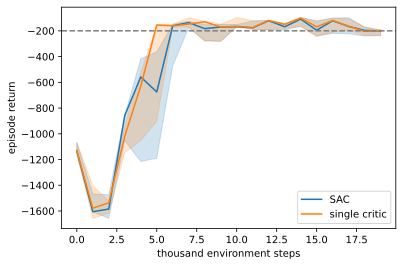

In [12]:
grid = np.arange(1, num_env_steps // 1000 + 1) * 1000

def on_grid(arm, col, k=5):
    """Trailing-k-episode averages, resampled onto the env-step grid."""
    out = []
    for r in runs[arm]:
        v = r[~np.isnan(r[:, col])]
        s = np.convolve(v[:, col], np.ones(k) / k, 'valid')
        out.append(np.interp(grid, v[k - 1:, 0], s))
    return np.stack(out)

def steps_to(r, level=-200, k=5):
    """First env step at which the trailing-k-episode average clears level."""
    s = np.convolve(r[:, 1], np.ones(k) / k, 'valid')
    hit = np.flatnonzero(s >= level)
    return int(r[hit[0] + k - 1, 0]) if len(hit) else None

d2l.plot_curves({arm: on_grid(arm, 1) for arm in runs},
                xlabel='thousand environment steps', ylabel='episode return',
                reference=-200)
for arm in runs:
    print(f'{arm}: env steps to a trailing five-episode average of -200: '
          f'{[steps_to(r) for r in runs[arm]]}')

Every seed of both variants starts near $-1200$ or below and crosses $-200$ before ten thousand environment steps, most after about five to eight thousand. For comparison, that section trained REINFORCE with a learned baseline on the same task for 300 updates of 8 episodes and 200 steps, or $480{,}000$ environment steps. That experiment reported improvement, but no seed reached $-200$. The comparison reflects two algorithmic differences. The pathwise gradient differentiates the actor objective through the critic, and replay permits multiple updates from collected transitions. The two variants are not distinguishable in this plot: their uncertainty bands overlap throughout training, and their crossing times have no consistent ordering across frameworks. At this budget, any effect of the second critic is not visible in the return curves, as in the two-action comparison in that section. The final experiment instead examines critic calibration.

### Policy Entropy and Temperature

The training loop records policy entropy because its coefficient $\alpha$
sets the objective's reward--entropy tradeoff. The dashed line shows the
commonly used autotuning target $-\dim\mathcal{A}=-1$:

SAC: entropy over the last 20 episodes, per seed [-0.03  0.04  0.07]
single critic: entropy over the last 20 episodes, per seed [-0.06  0.12  0.24]


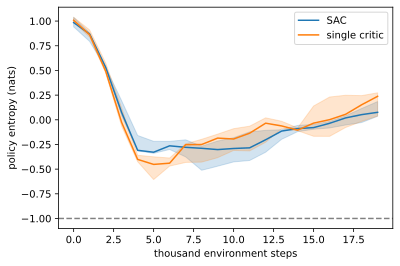

In [13]:
d2l.plot_curves({arm: on_grid(arm, 2) for arm in runs},
                xlabel='thousand environment steps',
                ylabel='policy entropy (nats)', reference=-1)
for arm in runs:
    print(f'{arm}: entropy over the last 20 episodes, per seed '
          f'{np.round([np.nanmean(r[-20:, 2]) for r in runs[arm]], 2)}')

The trace begins high, falls during the period of rapid return improvement,
and finishes near zero in both ablations. The policy remains stochastic;
for differential entropy, zero has no special status and negative values
simply indicate a sufficiently concentrated density.

Reported entropy depends on the density convention. We retain the
$\log c$ term in the equation; an implementation that omits it
would report the same policy lower by $\log 2\approx0.69$ nats in this
environment. Entropy values should therefore be compared only after
checking the action-scale convention.

We fix $\alpha=0.2$ in this diagnostic. The resulting entropy happens to
finish within about one nat of the common target
$\bar H=-\dim\mathcal{A}=-1$, but this single run does not justify the
coefficient generally. Temperature autotuning instead adjusts $\alpha$ to
enforce a chosen entropy constraint
[@Haarnoja.Zhou.Hartikainen.ea.2018]. The coefficient has units of
reward per nat and is reward-scale dependent; it is not a learning rate.

Training returns are generated by the stochastic policy because entropy is part of the objective. We therefore evaluate both that policy and the deterministic mean action $c\tanh(\mu_\theta(s))$:

In [14]:
env = gym.make('Pendulum-v1')
for arm in runs:
    for seed in range(num_seeds):
        agent = agents[arm][seed]
        env.reset(seed=100 + seed)
        g = d2l.evaluate(env, agent.actor.act_greedy, num_episodes=20)
        env.reset(seed=100 + seed)
        s = d2l.evaluate(env, agent.actor.act, num_episodes=20,
                         rng=np.random.default_rng(1000 + seed))
        print(f'{arm}, seed {seed}: deterministic {g:7.1f}, '
              f'stochastic {s:7.1f}, noise cost {g - s:+6.1f}')

SAC, seed 0: deterministic  -184.5, stochastic  -184.7, noise cost   +0.2


SAC, seed 1: deterministic  -141.9, stochastic  -148.4, noise cost   +6.5


SAC, seed 2: deterministic  -184.2, stochastic  -184.5, noise cost   +0.3


single critic, seed 0: deterministic  -183.6, stochastic  -182.7, noise cost   -0.9


single critic, seed 1: deterministic  -146.6, stochastic  -147.7, noise cost   +1.1


single critic, seed 2: deterministic  -183.3, stochastic  -183.5, noise cost   +0.2


Across variants and frameworks, deterministic returns lie between about $-140$ and $-190$, and the stochastic policy is within about ten points of its deterministic counterpart. The learned state-dependent standard deviation therefore preserves entropy with little loss of return on this task. Unlike fixed $\epsilon$-greedy exploration, the stochasticity is optimized jointly with the policy under the entropy-regularized objective.

### Critic Calibration: Predicted and Realized Returns

The critic variants differ more clearly in calibration than in return. For each trained agent, we run twenty stochastic episodes and compare $\min_j Q_{w_j}(s_0,a_0)$ with the realized return. A soft critic predicts the entropy-regularized return $\sum_t \gamma^t(r_t-\alpha\log\pi(a_t\mid s_t))$, so this quantity is the appropriate target; the ordinary return is reported alongside it.

In [15]:
def calibration(agent, seed, num_episodes=20):
    """Predicted min_j Q(s0, a0) against the realized discounted soft return."""
    rng, env = np.random.default_rng(seed), gym.make('Pendulum-v1')
    env.reset(seed=seed)
    preds, softs, plains = [], [], []
    for _ in range(num_episodes):
        obs, done, disc = env.reset()[0], False, 1.0
        soft = plain = 0.0
        first = True
        while not done:
            with torch.no_grad():
                mean, std = agent.actor(torch.as_tensor(obs))
                u = mean + std * torch.as_tensor(rng.standard_normal(
                    mean.shape, dtype=np.float32))
                logp = float(agent.actor.log_prob(u, mean, std))
            a = c * np.tanh(u.numpy())
            if first:
                with torch.no_grad():
                    preds.append(float(agent.min_q(
                        torch.as_tensor(obs), torch.as_tensor(a))))
                first = False
            obs, rew, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            soft += disc * (rew - alpha * logp)
            plain += disc * rew
            disc *= gamma
        softs.append(soft)
        plains.append(plain)
    return np.mean(preds), np.mean(softs), np.mean(plains)

for arm in runs:
    for seed in range(num_seeds):
        pred, soft, plain = calibration(agents[arm][seed], 200 + seed)
        print(f'{arm:>13}, seed {seed}: promised {pred:7.1f}, delivered '
              f'(soft) {soft:7.1f}, gap {pred - soft:+6.1f}, plain {plain:7.1f}')

          SAC, seed 0: promised  -175.1, delivered (soft)  -117.9, gap  -57.1, plain  -126.4


          SAC, seed 1: promised  -127.0, delivered (soft)   -89.7, gap  -37.3, plain   -98.1


          SAC, seed 2: promised  -177.1, delivered (soft)  -135.6, gap  -41.6, plain  -141.9


single critic, seed 0: promised  -119.6, delivered (soft)  -113.0, gap   -6.6, plain  -119.3


single critic, seed 1: promised   -86.5, delivered (soft)   -81.8, gap   -4.7, plain   -93.7


single critic, seed 2: promised  -144.2, delivered (soft)  -129.9, gap  -14.3, plain  -138.3


The result is consistent across seeds and frameworks. Neither variant substantially overestimates the realized soft return. The single critic's prediction is typically within thirty points, whereas the minimum of two critics underestimates the return by about thirty to sixty points. The absolute gap is larger for the twin-critic variant on every seed, consistent with taking a minimum. Some underestimation may also arise because the policy continues to improve while the critic tracks earlier data, so the comparison between variants is more informative than their absolute offsets. On Pendulum, the second critic changes calibration without improving the final policy. On harder tasks, pessimistic targets are intended to reduce feedback between critic overestimation and actor updates; that section uses related ideas without further interaction.

## Summary

SAC optimizes expected reward plus entropy. Soft policy evaluation adds $-\alpha\log\pi$ to the bootstrap target, and soft policy improvement uses a pathwise gradient through the critic. A tanh transformation enforces bounded actions; its log density must include the change-of-variables determinant, evaluated in a numerically stable form. Replay, Polyak-averaged target networks, and the minimum of two critics provide the off-policy value-learning machinery. No target actor or importance ratios are required.

**Experimental scope.** The density and soft-backup checks are deterministic. Training uses three seeds per method and framework. Every SAC run reaches return $-200$ within $10{,}000$ environment steps on Pendulum, while deterministic final evaluations lie roughly between $-140$ and $-190$. Twin and single critics have similar returns at this budget; the twin-critic minimum is more pessimistic in every calibration comparison. Exact crossing times and calibration gaps vary across seeds.

## Exercises

1. [short-code] *Autotune the temperature.* [@Haarnoja.Zhou.Hartikainen.ea.2018]
   replaces the fixed $\alpha$ by a constraint $E\big[ H(\pi(\cdot \mid s_t)) \big] \geq \bar{H}$
   with $\bar{H} = -\dim \mathcal{A}$, and lets $\alpha$ be the Lagrange
   multiplier, minimizing $J(\alpha) = E_{a \sim \pi}\big[ -\alpha (\log \pi(a \mid s) + \bar{H}) \big]$
   by gradient steps on $\log \alpha$. Add this to `train_sac` (a few lines:
   one extra parameter, updated from the `logp` the loop already computes),
   starting from $\alpha_0 = 1$. Plot $\alpha_t$ and the entropy trace. Does
   the entropy converge to $\bar{H}$, and where does $\alpha$ end up relative
   to the $0.2$ we fixed?
1. [short-code] *Delete the log-determinant.* Remove the `logdet` term from
   `log_prob` and retrain one seed. Report three readings: the return curve,
   the entropy trace, and the quadrature check. Which diagnostics expose the
   error, and why can the return curve fail to do so?
1. [conceptual] *Off-policy without ratios.* For each expectation in
   the equation and the equation, state the distribution it
   is taken under and which part the replay buffer supplies. Where
   that section needed importance ratios, why does nothing here need one,
   and what distribution shift does the buffer still introduce that no ratio
   over actions can repair?
1. [short-code] *Entropy is not monotone in the noise.* Estimate the squashed
   policy's entropy $-E[\log \pi]$ at fixed $\mu = 0$ and
   $\sigma \in \{0.1, 0.3, 1, 3\}$ by sampling $u$ and averaging
   `log_prob` (do not integrate over the action: the density near the
   boundary defeats a uniform grid). Explain why the entropy peaks at an
   intermediate $\sigma$ and falls as mass piles onto the boundary, and what
   that implies for an agent trying to raise its entropy by inflating
   $\sigma$.
1. [short-code] *The limit $\alpha \to 0$ is DDPG.* Show numerically that at
   $\alpha = 0$ and $\sigma \to 0$ the actor's gradient in
   the equation equals the pathwise gradient of
   the equation evaluated at the deterministic action
   $c \tanh(\mu_\theta(s))$, which is DDPG's actor update
   [@Lillicrap.Hunt.Pritzel.ea.2016]. Then list TD3's three repairs
   [@Fujimoto.vanHoof.Meger.2018] and say which two SAC kept and why the
   stochastic policy makes the third unnecessary.
1. [short-code] *Port it.* Move the section's code to `LunarLander-v3` with
   `continuous=True`, whose action is two-dimensional. List every line that
   changes and every line that does not, in the spirit of that section's
   port exercise; say which single hyperparameter you expect to raise most and
   why; check that `log_prob` still reduces correctly over the action axis;
   and explain what breaks, and where, if you instead port to `CartPole-v1`.
1. [extended] *Discrete soft actor-critic.* With a finite action set both
   expectations in the equation and the equation can be
   computed exactly by summing over actions, and no reparameterization is
   needed. Write both losses for a softmax policy, state what replaces the
   tanh machinery, and implement it on CartPole; compare its sample efficiency
   against that section's DQN at the same step budget.

[Discussions](https://d2l.discourse.group/)